### Import all the necessary library and frameworks

In [455]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score
)
import shap
import joblib
import os

### All the different file paths

In [456]:
data_path = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
importance_dir = "../data/feature_importance/per_country"
model_dir = "../models/per_country"
SHAP_DIR = "../data/shap_values"
metrics_dir = "../data/model_performance/per_country"

### Initial setup

In [457]:
drop_cols = ['date', 'Country']
random_state = 42
test_size = 0.2

### Ensuring that all folders exist

In [458]:
os.makedirs(importance_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

### Load the data

In [459]:
df = pd.read_excel(data_path)
df['date'] = pd.to_datetime(df['date'])

# Results
all_results = []

### Data cutoff for data split

In [460]:
train_start = "1995-01-01"
train_end   = "2009-12-31"
val_end     = "2018-12-31"
test_end    = "2024-05-31"

### Target country and target indicator
- Possible Countries: USA, CAN, MEX, GER, CHI, JAP
- Possible indicators: RECESS, RECESS_OVER, RECESS_PERIOD

In [787]:
country = "JAP"
target = "RECESS_PERIOD"

### Sanity check

In [788]:
df_country = df[df["Country"] == country].copy()

if df_country[target].nunique() < 2:
    print(f"[SKIP] Not enough variation for {target} in {country}")
else:
    print(f"[INFO] Proceeding with {country} — target: {target}")

[INFO] Proceeding with JAP — target: RECESS_PERIOD


### Data splits

In [789]:
# Drop non-feature columns
X = df_country.drop(columns=drop_cols + [target])
y = df_country[target]

# Time-based masks
train_mask = (df_country['date'] >= train_start) & (df_country['date'] <= train_end)
val_mask   = (df_country['date'] > train_end) & (df_country['date'] <= val_end)
test_mask  = (df_country['date'] > val_end) & (df_country['date'] <= test_end)

In [790]:
X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

In [791]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print(f"Train Date Range: {df_country[train_mask]['date'].min().date()} to {df_country[train_mask]['date'].max().date()}")
print(f"Validation Date Range: {df_country[val_mask]['date'].min().date()} to {df_country[val_mask]['date'].max().date()}")
print(f"Test Date Range: {df_country[test_mask]['date'].min().date()} to {df_country[test_mask]['date'].max().date()}")


Train: 180 samples
Validation: 108 samples
Test: 65 samples
Train Date Range: 1995-01-01 to 2009-12-01
Validation Date Range: 2010-01-01 to 2018-12-01
Test Date Range: 2019-01-01 to 2024-05-01


### Building the model

In [792]:
model = XGBClassifier(
    n_estimators=100,
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=random_state
)

In [793]:
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [06:46:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

###  Validating and testing the model

In [794]:
y_prob = model.predict_proba(X_test)[:, 1]

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

y_pred_final = (y_prob > best_thresh).astype(int)


### Model performance

In [795]:
auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
accuracy = accuracy_score(y_test, y_pred_final)

print(f"[TUNE] Best Threshold = {best_thresh:.2f}")
print(f"[EVAL] AUC = {auc:.3f}, Accuracy = {accuracy:.3f}, F1 = {best_f1:.3f}, Precision = {precision:.3f}, Recall = {recall:.3f}")


[TUNE] Best Threshold = 0.10
[EVAL] AUC = 0.819, Accuracy = 0.800, F1 = 0.711, Precision = 0.762, Recall = 0.667


### SHAP

In [796]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

print(f"\n Top features for {target} in {country}:")
print(mean_shap.head(10))



 Top features for RECESS_PERIOD in JAP:
IP (Index)_LAG12    3.718053
EPU (Index)_LAG3    1.094422
EPU (Index)_LAG1    0.768589
EPU (Index)_LAG6    0.508335
INF (%)_MA12        0.480930
CCI (Index)_LAG3    0.332143
IP (Index)          0.249413
RECESS              0.237000
INF (%)_LAG3        0.108863
INF (%)_LAG6        0.061289
dtype: float32


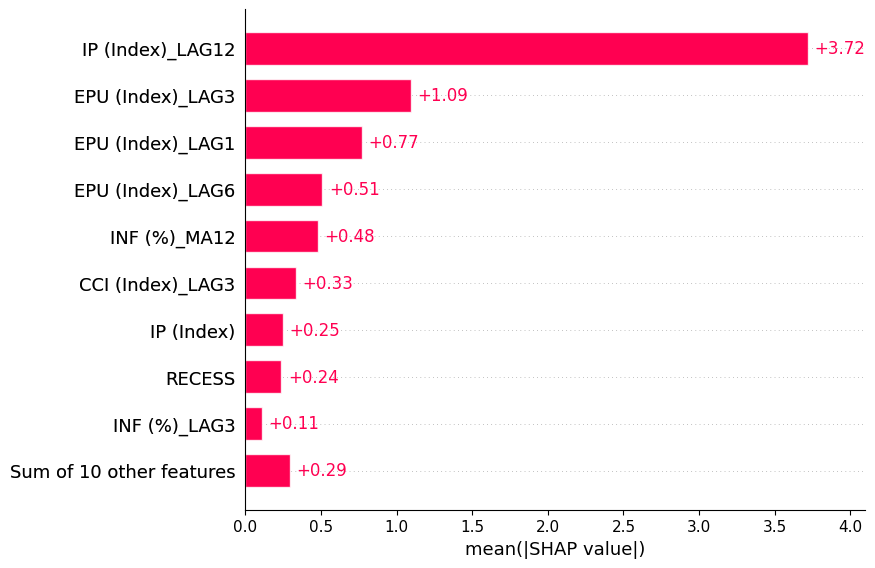

In [797]:
shap.plots.bar(shap_values[:, :20], show=True)

### Saving the plot

In [798]:
shap_plot_path = os.path.join(SHAP_DIR, f"XGB_SHAP_barplot_{target}.png")
plt.savefig(shap_plot_path, bbox_inches='tight', dpi=300)
plt.close()

print(f"[INFO] SHAP bar plot saved: {shap_plot_path}")

[INFO] SHAP bar plot saved: ../data/shap_values\XGB_SHAP_barplot_RECESS_PERIOD.png


### Saving the feature importances

In [799]:
base_name = f"{target}_{country.upper().replace(' ', '_')}_XGB"

# Save SHAP values
mean_shap.to_csv(f"{importance_dir}/SHAP_ranked_features_{base_name}.csv")

### Feature importances from XGBoost

In [800]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.to_csv(f"{importance_dir}/XGB_importance_{base_name}.csv")

### Storing the performance on a dataframe for display

In [801]:
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_final,
    "Probability": y_prob
})
pred_df.to_csv(f"{metrics_dir}/XGB_predictions_{base_name}.csv", index=False)

In [802]:
all_results.append({
    "Country": country,
    "Target": target,
    "AUC": auc,
    "F1": best_f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Threshold": best_thresh
})

In [803]:
results_df = pd.DataFrame(all_results)
results_df

,Country,Target,AUC,F1,Precision,Recall,Accuracy,Threshold
0,USA,RECESS,0.246032,0.066667,0.034483,1.000000,0.138462,0.33
1,CAN,RECESS,0.815826,0.645161,0.588235,0.714286,0.830769,0.89
2,MEX,RECESS,0.236520,0.000000,0.000000,0.000000,0.707692,0.50
3,GER,RECESS,0.333333,0.366667,0.255814,0.647059,0.415385,0.10
4,CHI,RECESS,0.824762,0.786885,0.923077,0.685714,0.800000,0.29
5,JAP,RECESS,0.896446,0.769231,0.681818,0.882353,0.861538,0.88
6,USA,RECESS_OVER,0.948770,0.571429,0.400000,1.000000,0.907692,0.53
7,CAN,RECESS_OVER,0.989035,0.933333,1.000000,0.875000,0.984615,0.79
8,MEX,RECESS_OVER,0.982249,0.866667,0.764706,1.000000,0.938462,0.13
9,GER,RECESS_OVER,0.649590,0.153846,0.111111,0.250000,0.830769,0.10


### Save the model performance

In [804]:
results_path = f"{metrics_dir}/XGB_per_country_results.csv"
results_df.to_csv(results_path, index=False)

print(f"[INFO] Results saved to: {results_path}")

[INFO] Results saved to: ../data/model_performance/per_country/XGB_per_country_results.csv


### Save the model

In [805]:
model_path = os.path.join(model_dir, f"XGB_model_{target}.pkl")
joblib.dump(model, model_path)

print(f"[INFO] Model saved: {model_path}")

[INFO] Model saved: ../models/per_country\XGB_model_RECESS_PERIOD.pkl
